In [1]:
import os
print(os.getcwd())

C:\Users\vidit\churn-prediction


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Basic exploration
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Check for missing values and data types
print("Missing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

print("\nChurn distribution:")
print(df['Churn'].value_counts())

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod       

In [5]:
# Fix TotalCharges - convert to number
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill any nulls created by conversion
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Convert Churn to 1/0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Convert all other Yes/No columns to 1/0
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# Convert gender to 1/0
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

# One-hot encode remaining categorical columns
df = pd.get_dummies(df, columns=['MultipleLines', 'InternetService', 
                                  'OnlineSecurity', 'OnlineBackup',
                                  'DeviceProtection', 'TechSupport',
                                  'StreamingTV', 'StreamingMovies',
                                  'Contract', 'PaymentMethod'])

# Drop customerID - not useful for modelling
df.drop('customerID', axis=1, inplace=True)

print("Shape after processing:", df.shape)
print("Churn distribution:\n", df['Churn'].value_counts())

Shape after processing: (7043, 41)
Churn distribution:
 Churn
0    5174
1    1869
Name: count, dtype: int64


C:\Users\vidit\AppData\Local\Temp\ipykernel_29788\131442967.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [6]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [7]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report

# Split into features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train XGBoost model
model = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                      use_label_encoder=False, eval_metric='logloss',
                      random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred_proba = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

y_pred = model.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

ROC-AUC Score: 0.8445

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



C:\Users\vidit\churn-prediction\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [04:33:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


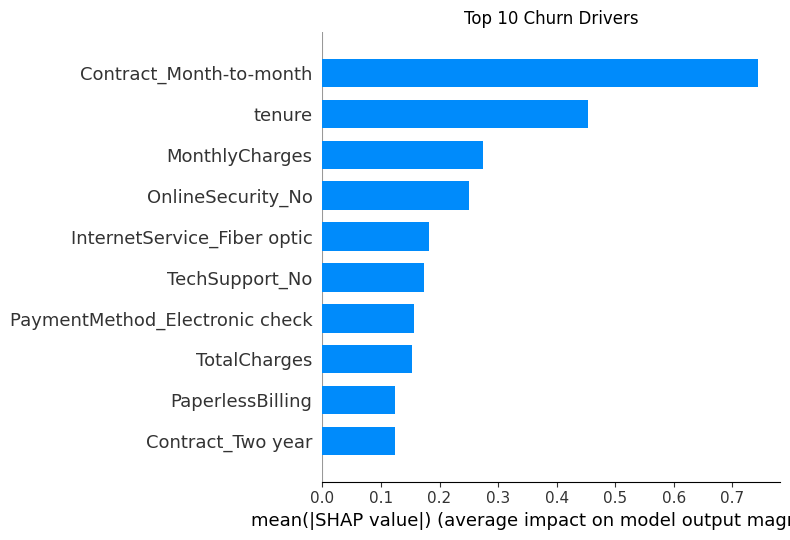

Saved: shap_feature_importance.png


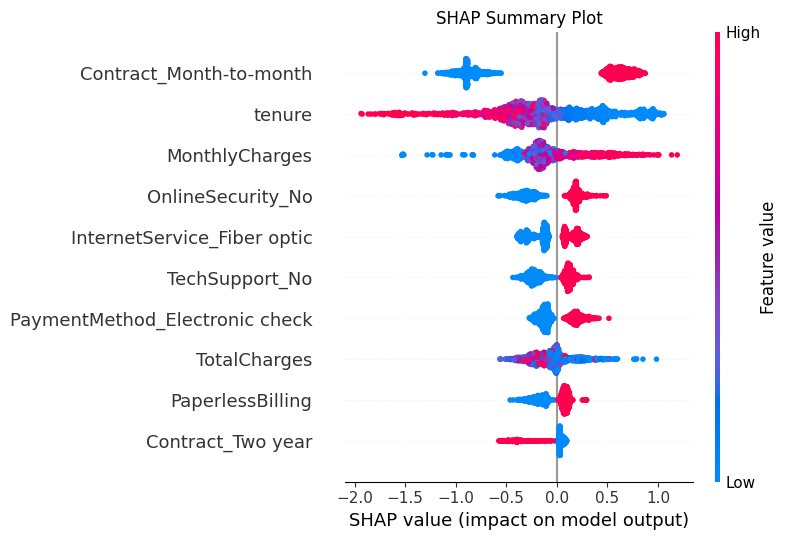

Saved: shap_summary.png


In [8]:
import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Plot 1 - Feature importance summary
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar", 
                  max_display=10, show=False)
plt.title("Top 10 Churn Drivers")
plt.tight_layout()
plt.savefig("shap_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_feature_importance.png")

# Plot 2 - Detailed SHAP dot plot
plt.figure()
shap.summary_plot(shap_values, X_test, max_display=10, show=False)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_summary.png")

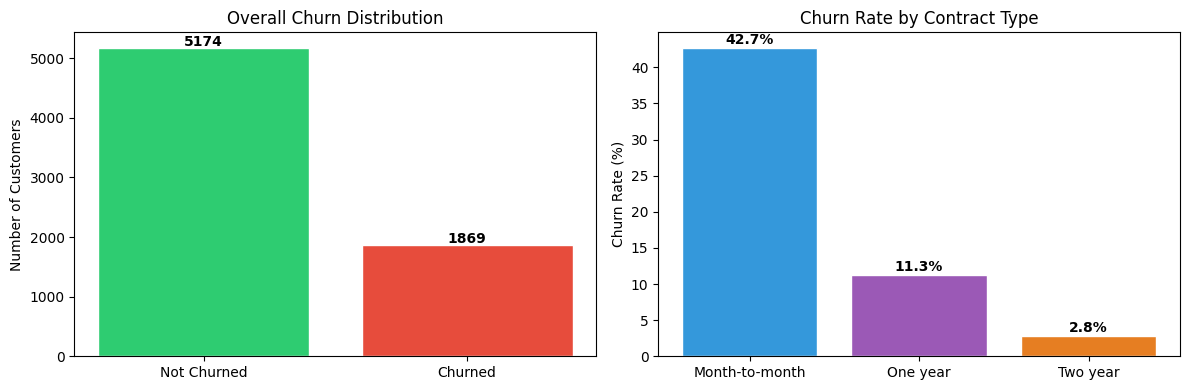

Saved: churn_distribution.png


In [9]:
# Plot 3 - Churn distribution chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall churn rate
churn_counts = pd.Series({'Not Churned': 5174, 'Churned': 1869})
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(churn_counts.index, churn_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Overall Churn Distribution')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Churn rate by contract type
original_df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
contract_churn = original_df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
)
axes[1].bar(contract_churn.index, contract_churn.values, 
            color=['#3498db', '#9b59b6', '#e67e22'], edgecolor='white')
axes[1].set_title('Churn Rate by Contract Type')
axes[1].set_ylabel('Churn Rate (%)')
for i, v in enumerate(contract_churn.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("churn_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: churn_distribution.png")